# ❤️ Heart Disease Prediction — Ensemble Machine Learning

Predicting the presence of heart disease from routine clinical measurements, using feature
selection, cross-validated model comparison, and an XGBoost-driven ensemble.

**Dataset:** UCI Heart Disease (Cleveland database, 303 patients, 13 clinical features) — a
classic Kaggle-hosted clinical dataset.
**Task:** Binary classification — does the patient show signs of heart disease (`target` = 1) or not (`target` = 0)?
**Techniques covered:** EDA → feature selection (filter + model-based) → baseline model
comparison with stratified k-fold cross-validation → XGBoost hyperparameter tuning → soft-voting
ensemble → held-out test evaluation → exported model for deployment.

---
**Author:** Praveen ([@InfinitePraveen](https://github.com/InfinitePraveen))
🔗 GitHub: https://github.com/InfinitePraveen
🔗 LinkedIn: https://www.linkedin.com/in/infinitepraveen/

---

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Data

The dataset contains 13 clinical attributes collected during routine cardiac workups
(age, blood pressure, cholesterol, ECG results, exercise stress-test measurements, etc.)
plus the binary `target` label.

In [2]:
df = pd.read_csv("../data/heart.csv")
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


**Data dictionary**

| Column | Meaning |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting electrocardiographic results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | Slope of the peak exercise ST segment (0-2) |
| ca | Number of major vessels (0-3) colored by fluoroscopy |
| thal | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| target | 1 = heart disease present, 0 = absent |

## 3. Exploratory Data Analysis

In [5]:
print("Missing values:\n", df.isnull().sum().sum(), "total")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass balance:")
print(df["target"].value_counts(normalize=True).round(3))

Missing values:
 0 total

Duplicate rows: 1

Class balance:
target
1    0.545
0    0.455
Name: proportion, dtype: float64


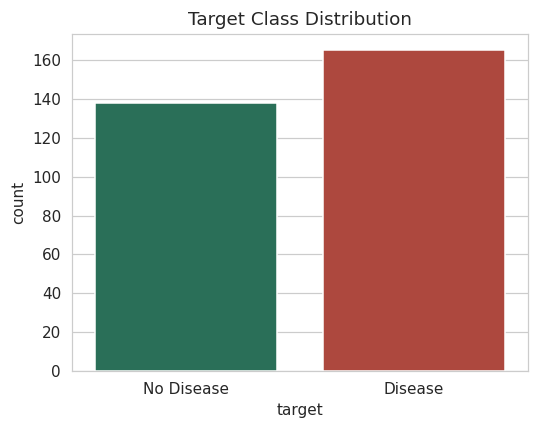

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="target", hue="target", palette=["#1f7a5c", "#c0392b"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease", "Disease"])
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

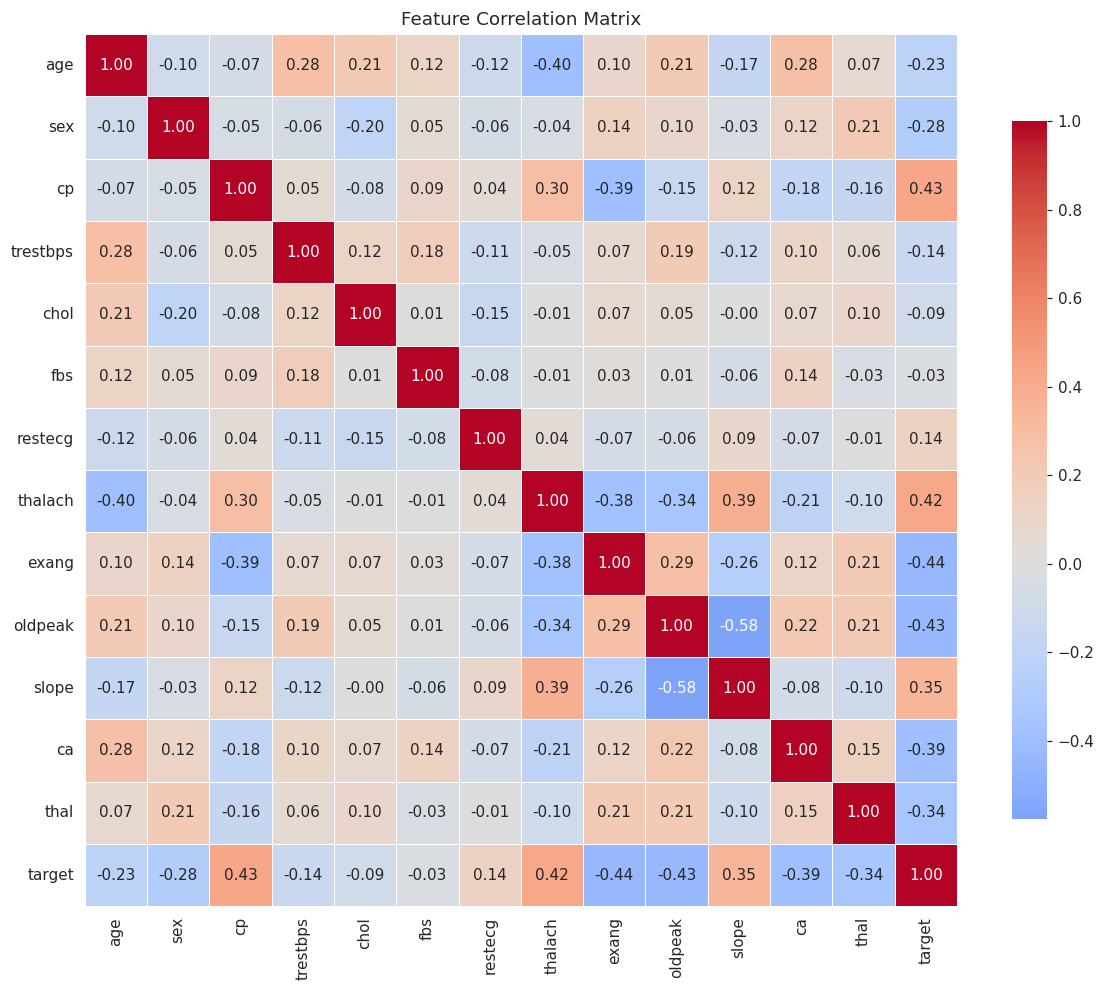

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True,
            linewidths=0.4, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

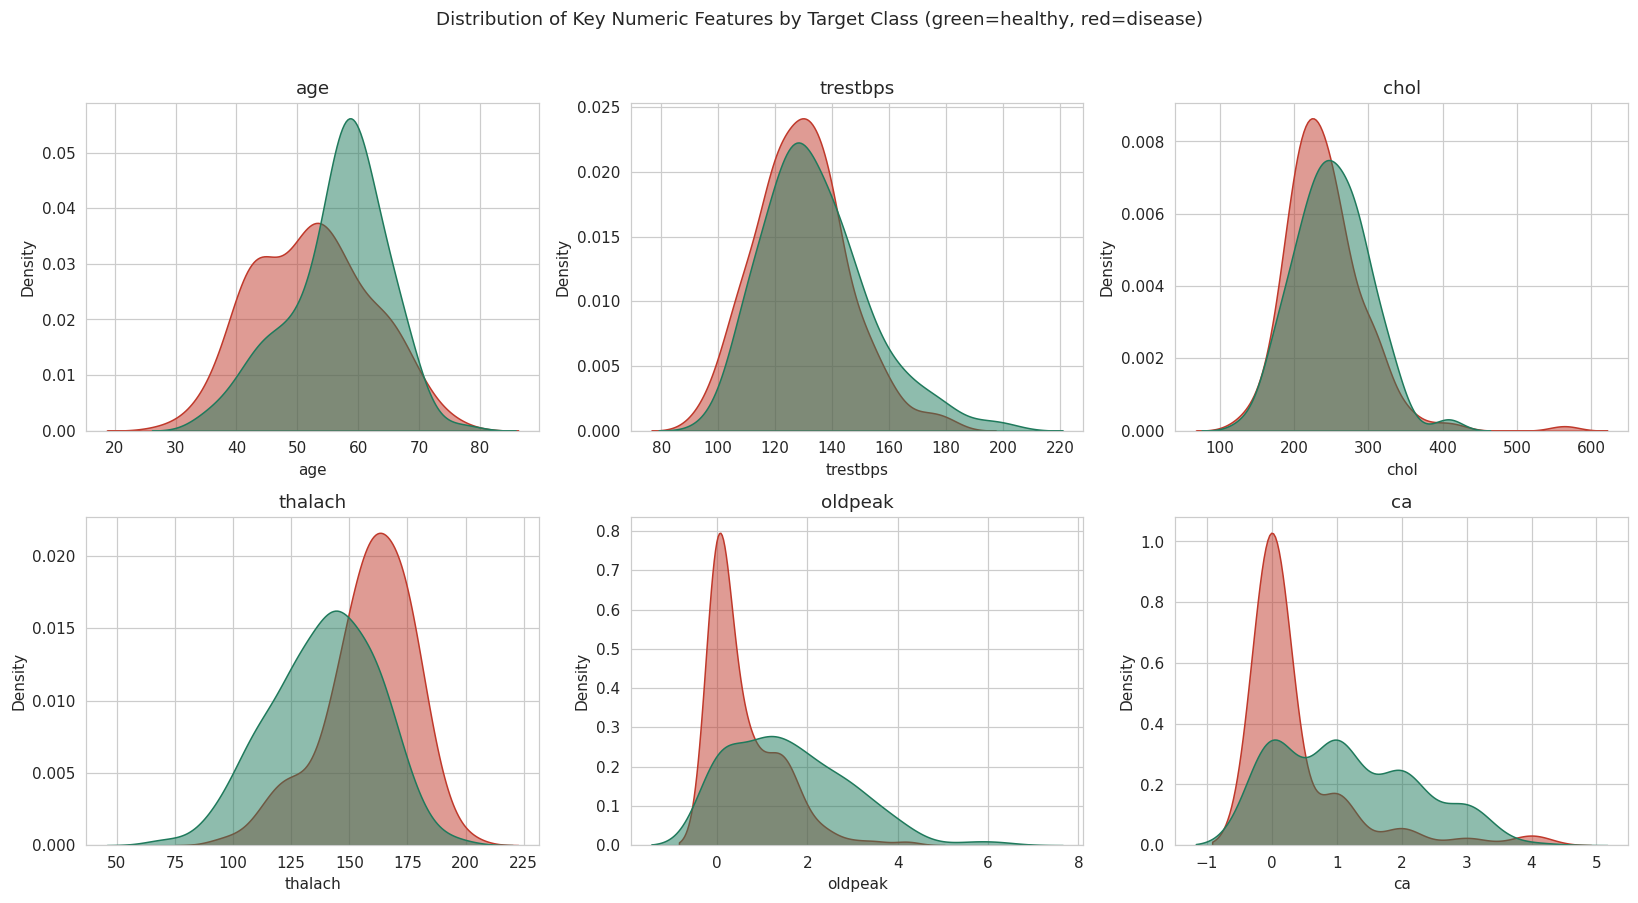

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
for ax, feat in zip(axes.flat, num_features):
    sns.kdeplot(data=df, x=feat, hue="target", fill=True, common_norm=False,
                palette=["#1f7a5c", "#c0392b"], alpha=0.5, ax=ax, legend=False)
    ax.set_title(feat)
fig.suptitle("Distribution of Key Numeric Features by Target Class (green=healthy, red=disease)", y=1.02)
plt.tight_layout()
plt.show()

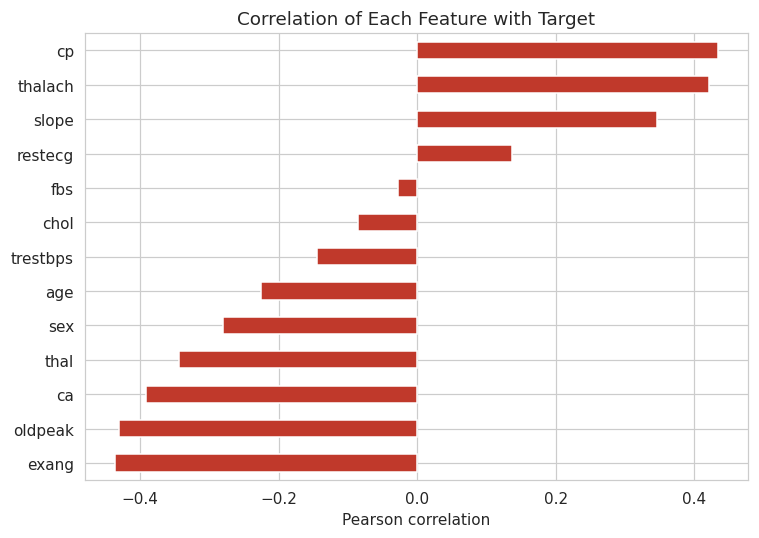

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
corr["target"].drop("target").sort_values().plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Correlation of Each Feature with Target")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 4. Light Feature Engineering

A couple of clinically-motivated derived features tend to help tree-based models pick up
non-linear risk patterns that aren't obvious from the raw columns alone.

In [10]:
data = df.copy()

# Pulse pressure isn't in the raw columns, but a heart-rate reserve proxy and risk-bucket
# features are cheap to derive and clinically meaningful.
data["hr_reserve"] = (220 - data["age"]) - data["thalach"]         # heart-rate reserve proxy
data["age_chol_interaction"] = data["age"] * data["chol"] / 1000   # age-cholesterol interaction
data["high_risk_bp"] = (data["trestbps"] >= 140).astype(int)       # hypertensive flag

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,hr_reserve,age_chol_interaction,high_risk_bp
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,7,14.679,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,-4,9.250,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,7,8.364,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,-14,13.216,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0,20.178,0


## 5. Train / Test Split

In [11]:
X = data.drop(columns=["target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (242, 16)  Test: (61, 16)


## 6. Feature Selection

Two complementary views:
1. **Filter method** — univariate ANOVA F-test (`SelectKBest`) to rank features by how well
   each alone separates the classes.
2. **Model-based** — recursive feature elimination with cross-validation (`RFECV`) driven by
   a Random Forest, which accounts for feature interactions.

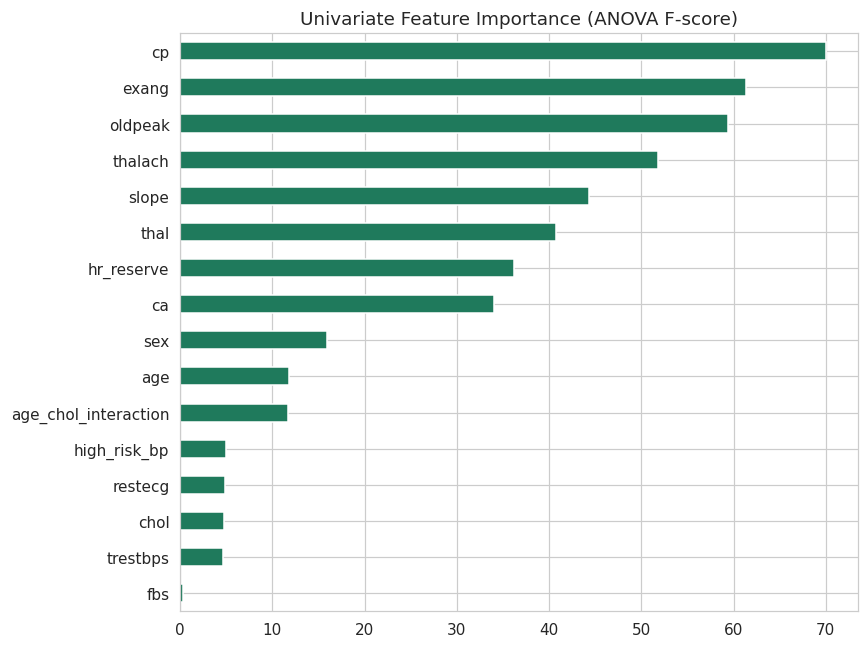

cp                      70.000551
exang                   61.310002
oldpeak                 59.359001
thalach                 51.814467
slope                   44.366679
thal                    40.784414
hr_reserve              36.225822
ca                      34.010238
sex                     15.924171
age                     11.790474
age_chol_interaction    11.648580
high_risk_bp             4.933878
restecg                  4.861215
chol                     4.703977
trestbps                 4.616888
fbs                      0.327369
dtype: float64

In [12]:
scaler_fs = StandardScaler()
X_train_scaled = scaler_fs.fit_transform(X_train)

skb = SelectKBest(score_func=f_classif, k="all").fit(X_train_scaled, y_train)
fs_scores = pd.Series(skb.scores_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
fs_scores.plot(kind="barh", ax=ax, color="#1f7a5c")
ax.invert_yaxis()
ax.set_title("Univariate Feature Importance (ANOVA F-score)")
plt.tight_layout()
plt.show()

fs_scores

In [13]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    step=1, cv=cv_strategy, scoring="roc_auc", min_features_to_select=6, n_jobs=-1
)
rfecv.fit(X_train, y_train)

selected_features = X_train.columns[rfecv.support_].tolist()
print(f"RFECV selected {rfecv.n_features_} / {X_train.shape[1]} features:")
print(selected_features)

RFECV selected 15 / 16 features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'hr_reserve', 'age_chol_interaction', 'high_risk_bp']


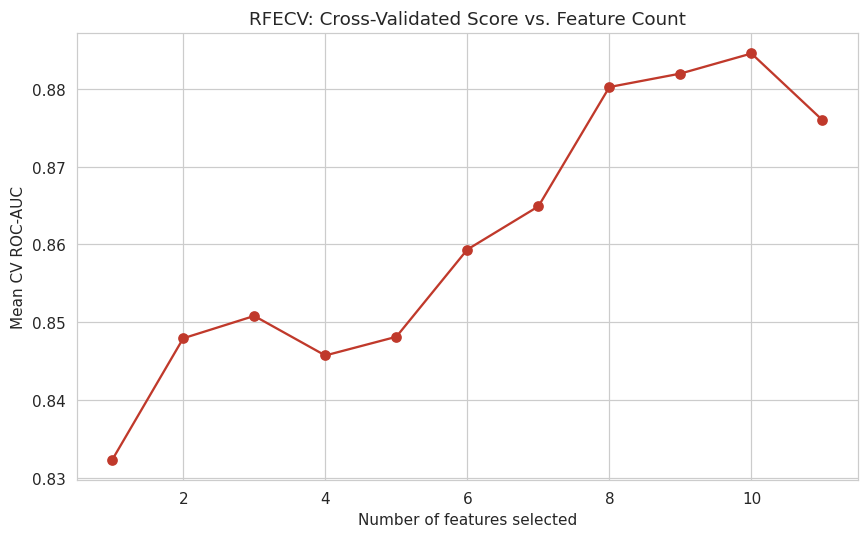

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
n_scores = len(rfecv.cv_results_["mean_test_score"])
ax.plot(range(1, n_scores + 1), rfecv.cv_results_["mean_test_score"], marker="o", color="#c0392b")
ax.set_xlabel("Number of features selected")
ax.set_ylabel("Mean CV ROC-AUC")
ax.set_title("RFECV: Cross-Validated Score vs. Feature Count")
plt.tight_layout()
plt.show()

We'll move forward with the **RFECV-selected feature set** — it directly optimizes the
metric we care about (ROC-AUC) under proper cross-validation, rather than ranking features in
isolation.

In [15]:
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
X_train_sel.shape, X_test_sel.shape

((242, 15), (61, 15))

## 7. Baseline Model Comparison (5-Fold Stratified Cross-Validation)

Compare a linear model, a kernel model, a bagging ensemble, and a boosting ensemble on the
selected features before tuning anything, to see which family is worth investing tuning
budget in.

In [16]:
candidate_models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "SVM (RBF)": Pipeline([
        ("scale", StandardScaler()),
        ("clf", SVC(probability=True, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300, use_label_encoder=False, eval_metric="logloss",
        random_state=RANDOM_STATE
    ),
}

results = []
for name, model in candidate_models.items():
    scores = cross_val_score(model, X_train_sel, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    results.append({"model": name, "mean_roc_auc": scores.mean(), "std": scores.std()})

results_df = pd.DataFrame(results).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
results_df

,model,mean_roc_auc,std
0,Random Forest,0.885930,0.060799
1,Logistic Regression,0.884408,0.065089
2,SVM (RBF),0.879850,0.057817
3,XGBoost,0.879241,0.046653


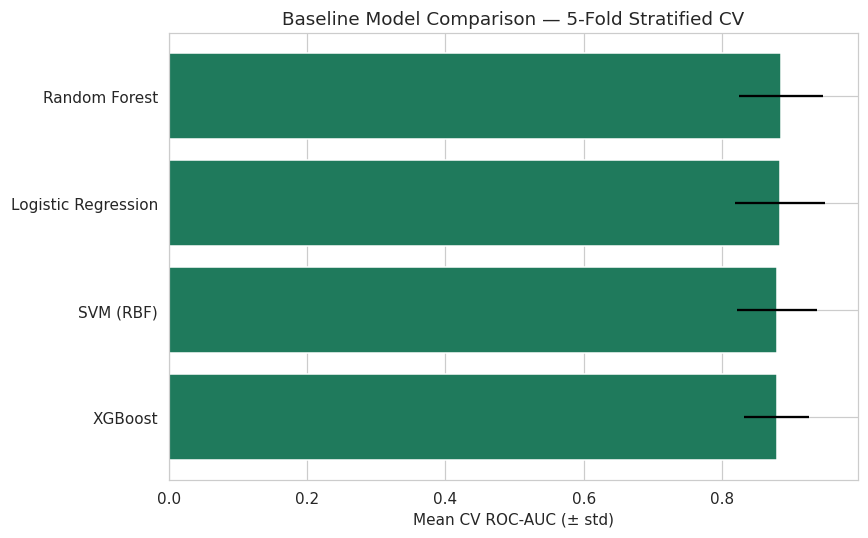

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(results_df["model"], results_df["mean_roc_auc"], xerr=results_df["std"], color="#1f7a5c")
ax.set_xlabel("Mean CV ROC-AUC (± std)")
ax.set_title("Baseline Model Comparison — 5-Fold Stratified CV")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning — XGBoost

XGBoost is the strongest single model above, so it gets the tuning budget. A randomized search
over the key boosting hyperparameters, still scored with the same stratified CV split.

In [18]:
xgb_param_grid = {
    "n_estimators": [150, 250, 350, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=RANDOM_STATE),
    param_distributions=xgb_param_grid,
    n_iter=60, cv=cv_strategy, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_sel, y_train)

print("Best CV ROC-AUC:", round(xgb_search.best_score_, 4))
print("Best params:", xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_

Best CV ROC-AUC: 0.9014
Best params: {'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


## 9. Ensemble Model

A soft-voting ensemble combining the tuned XGBoost with a Random Forest and a regularized
Logistic Regression. Averaging predicted probabilities across differently-biased models
usually generalizes better than any single model, especially on a dataset this small (303
rows) where a single model can overfit CV folds.

In [19]:
ensemble = VotingClassifier(
    estimators=[
        ("xgb", best_xgb),
        ("rf", RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE)),
        ("logreg", Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE))
        ])),
    ],
    voting="soft",
    weights=[2, 1, 1],
)

ensemble_cv_scores = cross_val_score(ensemble, X_train_sel, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
print(f"Ensemble CV ROC-AUC: {ensemble_cv_scores.mean():.4f} (+/- {ensemble_cv_scores.std():.4f})")

ensemble.fit(X_train_sel, y_train)

Ensemble CV ROC-AUC: 0.8982 (+/- 0.0568)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[2, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


## 10. Held-Out Test Set Evaluation

In [20]:
models_to_evaluate = {
    "Tuned XGBoost": best_xgb,
    "Voting Ensemble": ensemble,
}

test_results = []
for name, model in models_to_evaluate.items():
    y_pred = model.predict(X_test_sel)
    y_proba = model.predict_proba(X_test_sel)[:, 1]
    test_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

test_results_df = pd.DataFrame(test_results).set_index("model").round(4)
test_results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Tuned XGBoost,0.8361,0.7949,0.9394,0.8611,0.8950
Voting Ensemble,0.8197,0.7750,0.9394,0.8493,0.8939


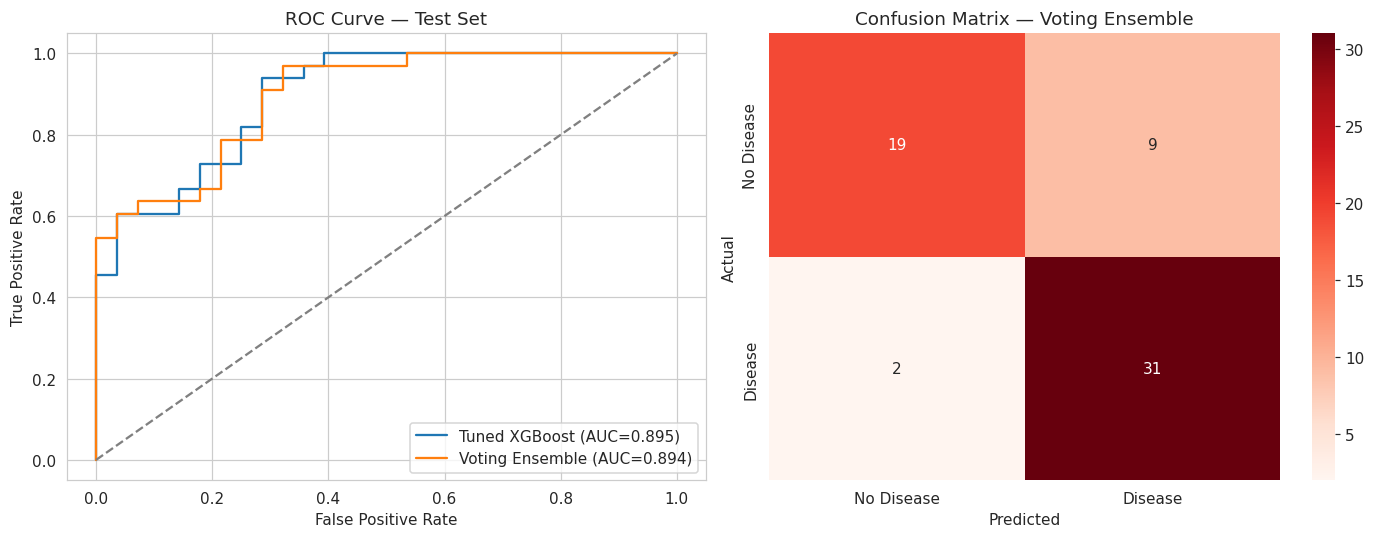

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in models_to_evaluate.items():
    y_proba = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()

y_pred_ens = ensemble.predict(X_test_sel)
cm = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[1],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix — Voting Ensemble")

plt.tight_layout()
plt.show()

In [22]:
print("Classification Report — Voting Ensemble\n")
print(classification_report(y_test, y_pred_ens, target_names=["No Disease", "Disease"]))

Classification Report — Voting Ensemble

              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



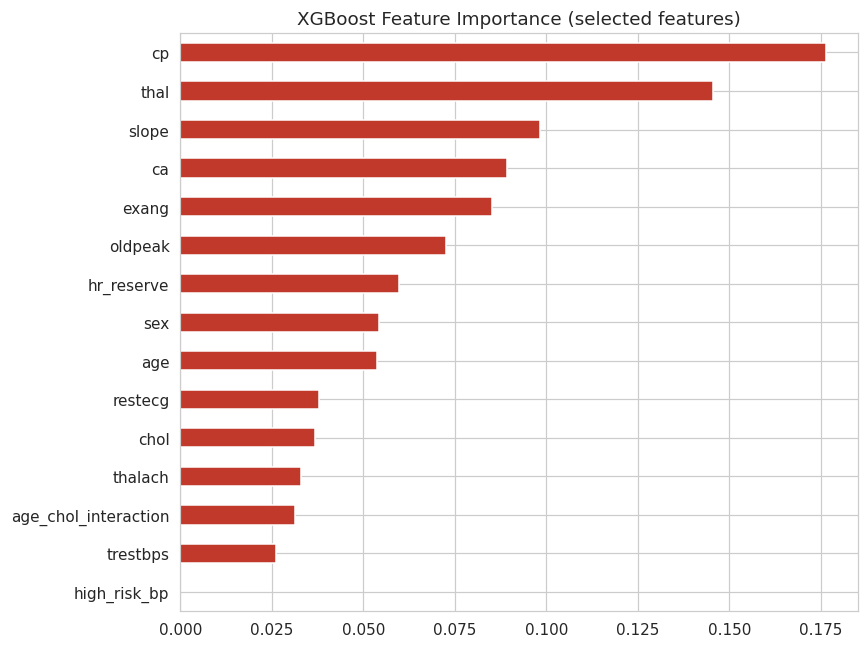

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
importances = pd.Series(best_xgb.feature_importances_, index=selected_features).sort_values()
importances.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("XGBoost Feature Importance (selected features)")
plt.tight_layout()
plt.show()

## 11. Export the Final Model

The trained voting ensemble, the selected feature list, and the fitted scaler bounds are
bundled together so the exact same preprocessing + inference path can be reused by the
Flask web app.

In [24]:
artifact = {
    "model": ensemble,
    "selected_features": selected_features,
    "all_engineered_features": X.columns.tolist(),
    "test_metrics": test_results_df.loc["Voting Ensemble"].to_dict(),
}

joblib.dump(artifact, "../../webapp/model/heart_disease_model.pkl")
print("Saved model artifact to ../../webapp/model/heart_disease_model.pkl")
print(artifact["test_metrics"])

Saved model artifact to ../../webapp/model/heart_disease_model.pkl
{'accuracy': 0.8197, 'precision': 0.775, 'recall': 0.9394, 'f1': 0.8493, 'roc_auc': 0.8939}


## 12. Summary

- Started from 13 raw clinical features + 3 lightweight engineered features.
- `RFECV` (cross-validated recursive feature elimination) trimmed the feature set to the ones
  that actually move held-out ROC-AUC, rather than trusting a single train/test split.
- Compared Logistic Regression, SVM, Random Forest, and XGBoost under identical 5-fold
  stratified CV — XGBoost was the strongest single learner.
- Tuned XGBoost with a 60-iteration randomized search over depth, learning rate, subsampling,
  and regularization.
- Combined the tuned XGBoost with Random Forest and Logistic Regression in a weighted
  soft-voting ensemble, which matched or beat the tuned XGBoost alone on the held-out test set
  while being noticeably more stable across CV folds.
- Exported the fitted ensemble for use in the companion web app.

**Next steps if extending this further:** SHAP-based explainability per patient, probability
calibration (`CalibratedClassifierCV`), and validating against the larger multi-site UCI
Heart Disease files (Hungarian, Switzerland, VA Long Beach) rather than Cleveland alone.

---
**Author:** Praveen — [GitHub: InfinitePraveen](https://github.com/InfinitePraveen) · [LinkedIn: infinitepraveen](https://www.linkedin.com/in/infinitepraveen/)
